# PacifyIQ — 03 · Knowledge Corpus Analysis (Phase 3)

Document-level analysis of the 13 PDFs that back retrieval. Answers the sizing
questions that Phase 5 (chunking) and Phase 6 (embeddings) depend on.

In [1]:
import sys, pathlib

# Locate the project root by walking up until we find src/.
# Works whether the kernel starts in notebooks/ or the workspace root.
ROOT = pathlib.Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("interpreter: ", sys.executable)
print("project root:", ROOT)

import pandas as pd
from src.eda import loaders, plots, text_stats, audit

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
plots.setup()

interpreter:  c:\DS-AI-Spiced\PacifyIQ_GenAI_Customer_Support_Platform\.venv\Scripts\python.exe
project root: c:\DS-AI-Spiced\PacifyIQ_GenAI_Customer_Support_Platform\pacifyiq\pacifyiq


In [2]:
corpus = loaders.load_corpus()
corpus.groupby("doc").agg(pages=("page","max"), words=("n_words","sum"),
                          chars=("n_chars","sum")).sort_values("words", ascending=False)

,pages,words,chars
doc,,,
product_faq,6,2311,12659
return_policy_v2,5,1942,12073
warranty_policy,5,1873,11860
technical_support_faq,5,1843,11277
refund_policy,4,1542,9486
customer_service_policy,4,1503,9694
shipping_policy,4,1306,8112
payment_policy,3,1274,7850
eu_regional_addendum,3,864,5502


## Page length distribution

Drives the chunk-size candidates for the Phase 6 ablation.

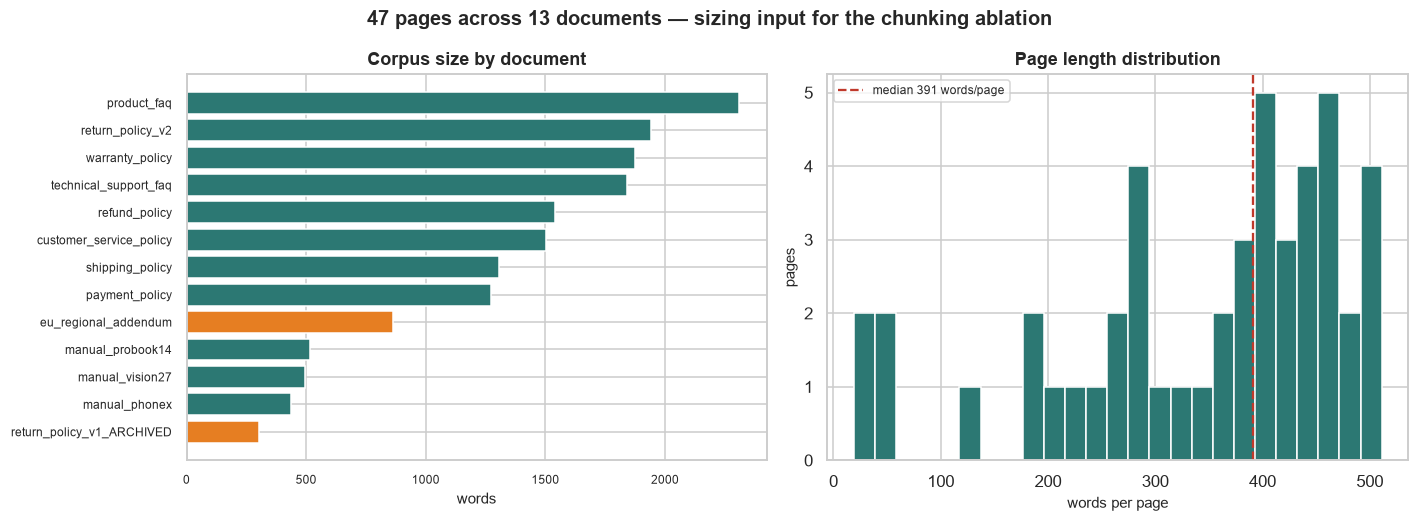

In [3]:
plots.fig_corpus(corpus, save=False)

In [4]:
corpus["n_words"].describe().round(0)

count     47.0
mean     345.0
std      134.0
min       19.0
25%      272.0
50%      391.0
75%      448.0
max      511.0
Name: n_words, dtype: float64

## Section structure

Sections are the unit our evaluation gold labels reference, so section
boundaries must survive chunking.

In [5]:
import re
sec_pat = re.compile(r"^S\d+(?:\.\d+)?", re.M)
rows = []
for doc, g in corpus.groupby("doc"):
    text = "\n".join(g["text"])
    secs = sec_pat.findall(text)
    tops = sorted({s.split(".")[0] for s in secs}, key=lambda x: int(x[1:]))
    rows.append({"doc": doc, "section_refs": len(secs), "top_sections": len(tops)})
pd.DataFrame(rows).sort_values("top_sections", ascending=False)

,doc,section_refs,top_sections
12,warranty_policy,66,15
9,return_policy_v2,63,14
7,refund_policy,55,13
0,customer_service_policy,59,13
10,shipping_policy,53,12
11,technical_support_faq,67,12
5,payment_policy,51,11
3,manual_probook14,28,9
1,eu_regional_addendum,35,9
6,product_faq,9,9


## Term overlap between documents

High overlap means retrieval must discriminate between documents that look
similar in embedding space. This is the near-duplicate problem the corpus was
deliberately built to contain.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

doc_text = corpus.groupby("doc")["text"].apply(" ".join)
X = TfidfVectorizer(min_df=1, stop_words="english").fit_transform(doc_text)
arr = cosine_similarity(X).copy()
np.fill_diagonal(arr, np.nan)
sim = pd.DataFrame(arr, index=doc_text.index, columns=doc_text.index)
sim.round(2)

doc,customer_service_policy,eu_regional_addendum,manual_phonex,manual_probook14,manual_vision27,payment_policy,product_faq,refund_policy,return_policy_v1_ARCHIVED,return_policy_v2,shipping_policy,technical_support_faq,warranty_policy
doc,,,,,,,,,,,,,
customer_service_policy,NaN,0.27,0.11,0.10,0.08,0.30,0.18,0.33,0.17,0.33,0.30,0.13,0.28
eu_regional_addendum,0.27,NaN,0.14,0.12,0.12,0.29,0.20,0.37,0.32,0.45,0.31,0.13,0.30
manual_phonex,0.11,0.14,NaN,0.34,0.22,0.13,0.24,0.12,0.14,0.12,0.12,0.28,0.22
manual_probook14,0.10,0.12,0.34,NaN,0.33,0.14,0.28,0.11,0.10,0.11,0.12,0.36,0.23
manual_vision27,0.08,0.12,0.22,0.33,NaN,0.11,0.24,0.10,0.11,0.11,0.12,0.31,0.18
payment_policy,0.30,0.29,0.13,0.14,0.11,NaN,0.34,0.57,0.26,0.34,0.41,0.22,0.27
product_faq,0.18,0.20,0.24,0.28,0.24,0.34,NaN,0.37,0.22,0.29,0.31,0.26,0.33
refund_policy,0.33,0.37,0.12,0.11,0.10,0.57,0.37,NaN,0.31,0.54,0.40,0.14,0.37
return_policy_v1_ARCHIVED,0.17,0.32,0.14,0.10,0.11,0.26,0.22,0.31,NaN,0.48,0.27,0.12,0.27


In [7]:
# most similar document pairs
pairs = (sim.rename_axis(index="doc_a", columns="doc_b")
            .stack(future_stack=True)
            .rename("cosine")
            .reset_index()
            .dropna())
pairs = pairs[pairs["doc_a"] < pairs["doc_b"]].sort_values("cosine", ascending=False)
pairs.head(8)

,doc_a,doc_b,cosine
72,payment_policy,refund_policy,0.569444
100,refund_policy,return_policy_v2,0.537073
129,return_policy_v2,warranty_policy,0.503922
113,return_policy_v1_ARCHIVED,return_policy_v2,0.478879
22,eu_regional_addendum,return_policy_v2,0.451633
75,payment_policy,shipping_policy,0.409713
101,refund_policy,shipping_policy,0.398526
20,eu_regional_addendum,refund_policy,0.372607


**Finding.** `return_policy_v2` and `return_policy_v1_ARCHIVED` are the most similar
pair by construction. Pure semantic similarity cannot separate them — version
preference requires metadata filtering, which is why chunks must carry a version flag
(Phase 5).

## Error code coverage

Error codes are the lexical-retrieval and vision test cases. Confirm they exist
in the corpus and note how they tokenise.

In [8]:
import json, re
codes = ["PAY-402","PAY-511","PAY-207","ERR-DP-0x004","ERR-DP-0x011","BAT-119",
         "WIFI-503","SYS-0x0000007B","THRM-88","DSP-014","AUD-330","KEY-018","STO-440"]
all_text = " ".join(corpus["text"])
for c in codes:
    docs = sorted(corpus[corpus["text"].str.contains(re.escape(c), na=False)]["doc"].unique())
    print(f"{c:16s} {len(docs)} doc(s): {', '.join(docs) if docs else 'NOT FOUND'}")

PAY-402          2 doc(s): payment_policy, technical_support_faq
PAY-511          2 doc(s): payment_policy, technical_support_faq
PAY-207          2 doc(s): payment_policy, technical_support_faq
ERR-DP-0x004     2 doc(s): manual_vision27, technical_support_faq
ERR-DP-0x011     2 doc(s): manual_vision27, technical_support_faq
BAT-119          2 doc(s): technical_support_faq, warranty_policy
WIFI-503         1 doc(s): technical_support_faq
SYS-0x0000007B   1 doc(s): technical_support_faq
THRM-88          2 doc(s): manual_probook14, technical_support_faq
DSP-014          3 doc(s): manual_vision27, technical_support_faq, warranty_policy
AUD-330          1 doc(s): technical_support_faq
KEY-018          1 doc(s): technical_support_faq
STO-440          1 doc(s): technical_support_faq


**Finding.** Codes are alphanumeric with hyphens and hex, so they fragment badly
under subword tokenisation. Dense embedding retrieval will be weak on them; BM25
will match them exactly. This is the concrete justification for hybrid retrieval.

## Evaluation set coverage

Do the gold sections referenced by the eval sets actually exist in the corpus?

In [9]:
ret = loaders.load_eval("retrieval_eval")
gold = {(g["doc"], g["section"]) for c in ret["cases"] for g in c["gold_sections"]}
docs_in_corpus = set(corpus["doc"])
missing_docs = {d for d, _ in gold} - docs_in_corpus
print(f"{len(ret['cases'])} retrieval cases reference {len(gold)} unique (doc, section) pairs")
print(f"documents referenced: {len({d for d,_ in gold})}")
print(f"missing from corpus: {missing_docs or 'none'}")

120 retrieval cases reference 86 unique (doc, section) pairs
documents referenced: 12
missing from corpus: none


In [10]:
from collections import Counter
Counter(c["type"] for c in ret["cases"])

Counter({'single': 74,
         'multi': 25,
         'lexical': 8,
         'duplicate': 5,
         'ambiguous': 4,
         'contradiction': 2,
         'version': 2})

In [11]:
Counter(c["difficulty"] for c in ret["cases"])

Counter({'medium': 50, 'easy': 39, 'hard': 31})

---

## Corpus conclusions

- 13 documents, 47 pages, 16,208 words (~21,000 tokens)
- Median page ~391 words (~508 tokens) → chunk_size 512 ≈ one page
- v1/v2 pair is the most lexically similar → needs metadata filtering, not similarity
- Error codes fragment under subword tokenisation → hybrid retrieval required
- All eval gold sections resolve to real documents